In [ ]:
# ── Cell # =============================================================
# MODEL 4 — TEAM FORMATION — FEATURE EXTRACTION
# Grain: one row per team (team_id)
# Target: actual_performance_score (regression)
# =============================================================

In [2]:
# ── Cell 1 — Imports & Config ─────────────────────────────────

import pandas as pd
import numpy as np
import json
import os
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# ── SET YOUR PATHS HERE ───────────────────────────────────────
INPUT_DIR  = "../../dataset_v2"
OUTPUT_DIR = "FT3"
# ─────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Libraries loaded ✅")

Libraries loaded ✅


In [3]:
# ── Cell 2 — Load Datasets ────────────────────────────────────

emp  = pd.read_csv(f"{INPUT_DIR}/employees.csv")
tf   = pd.read_csv(f"{INPUT_DIR}/team_formations.csv")
pr   = pd.read_csv(f"{INPUT_DIR}/performance_reviews.csv")
wh   = pd.read_csv(f"{INPUT_DIR}/workload_history.csv")
proj = pd.read_csv(f"{INPUT_DIR}/projects.csv")

print("Shapes:")
print(f"  employees        : {emp.shape}")
print(f"  team_formations  : {tf.shape}")
print(f"  performance_rev  : {pr.shape}")
print(f"  workload_history : {wh.shape}")
print(f"  projects         : {proj.shape}")

Shapes:
  employees        : (2000, 42)
  team_formations  : (1500, 40)
  performance_rev  : (4000, 55)
  workload_history : (110369, 50)
  projects         : (1000, 43)


In [4]:
# ── Cell 3 — Clean employees.csv ─────────────────────────────

emp['hire_date']   = pd.to_datetime(emp['hire_date'], format='mixed')
emp['tenure_days'] = (pd.Timestamp.today() - emp['hire_date']).dt.days

for col in ['is_available', 'cross_functional_experience', 'mentoring_experience']:
    emp[col] = emp[col].astype(bool)

emp['certifications'] = emp['certifications'].fillna('')
emp.drop(columns=['past_team_members'], inplace=True, errors='ignore')  # all null in dataset

# Ordinal encodings
seniority_order = {'Junior': 1, 'Mid': 2, 'Senior': 3, 'Lead': 4, 'Principal': 5}
stress_order    = {'Low': 1, 'Medium': 2, 'High': 3}
trend_order     = {'Decreasing': -1, 'Stable': 0, 'Increasing': 1}

emp['seniority_encoded']      = emp['seniority_level'].map(seniority_order)
emp['stress_encoded']         = emp['stress_level'].map(stress_order)
emp['productivity_trend_enc'] = emp['productivity_trend'].map(trend_order)

# Skills — merge primary + secondary, lowercase for consistent matching
emp['all_skills_list'] = (
    emp['primary_skills'].fillna('') + ',' + emp['secondary_skills'].fillna('')
).str.split(',').apply(lambda x: [s.strip().lower() for s in x if s.strip()])

# Derived: project success ratio (safer than raw counts)
emp['project_success_rate'] = (
    emp['successful_project_count'] /
    (emp['successful_project_count'] + emp['failed_project_count'])
).fillna(0)

print(f"employees.csv cleaned ✅  |  shape: {emp.shape}")

employees.csv cleaned ✅  |  shape: (2000, 47)


In [5]:
# ── Cell 4 — Clean performance_reviews.csv ───────────────────
# Use latest review per employee only.
# Pulling scores that supplement (not duplicate) employees.csv.

pr['review_date'] = pd.to_datetime(pr['review_date'], format='mixed')

pr_latest = (
    pr.sort_values('review_date', ascending=False)
      .groupby('employee_id', as_index=False)
      .first()
)

pr_keep = [
    'employee_id',
    'overall_performance_score',
    'on_time_delivery_rate',
    'productivity_vs_peers',
    'problem_solving_score',
    'innovation_score',
    'reliability_score',
    'time_management_score',
    'adaptability_score',
    'technical_competence_score',
]
pr_latest = pr_latest[pr_keep].rename(columns={
    'overall_performance_score' : 'review_performance_score',
    'technical_competence_score': 'review_technical_score',
})

print(f"performance_reviews.csv cleaned ✅  |  employees with reviews: {pr_latest['employee_id'].nunique()}")

performance_reviews.csv cleaned ✅  |  employees with reviews: 1705


In [6]:
# ── Cell 5 — Clean workload_history.csv ──────────────────────
# Use last 8 weeks for recency. Captures current load state.

wh['date'] = pd.to_datetime(wh['date'], format='mixed')
cutoff     = wh['date'].max() - pd.Timedelta(weeks=8)
wh_recent  = wh[wh['date'] >= cutoff].copy()

print(f"Workload records in last 8 weeks : {len(wh_recent)}")
print(f"Employees covered                : {wh_recent['employee_id'].nunique()} / {emp['employee_id'].nunique()}")

wh_agg = wh_recent.groupby('employee_id').agg(
    recent_avg_hours        = ('total_hours_worked',    'mean'),
    recent_avg_overtime     = ('overtime_hours',         'mean'),
    recent_workload_pct     = ('workload_vs_capacity',   'mean'),
    recent_avg_productivity = ('productivity_score',     'mean'),
    recent_focus_hours      = ('focused_work_hours',     'mean'),
    late_hours_count        = ('late_hours_indicator',   'sum'),
    weekend_work_count      = ('weekend_work_indicator', 'sum'),
).reset_index()

print("workload_history.csv aggregated ✅")

Workload records in last 8 weeks : 345
Employees covered                : 315 / 2000
workload_history.csv aggregated ✅


In [7]:
# ── Cell 6 — Build Master Employee Table ─────────────────────
# One row per employee. All member-level features live here.
# Team features are aggregated from this in Cell 10.

master = emp.copy()

master = master.merge(pr_latest, on='employee_id', how='left')
master = master.merge(wh_agg,    on='employee_id', how='left')

# Derived: remaining capacity this week
# Fallback: assume 70% utilized if no recent workload data
master['available_hours'] = (
    master['weekly_capacity_hours'] - master['recent_avg_hours'].fillna(
        master['weekly_capacity_hours'] * 0.7
    )
).clip(lower=0)

# Sanity check — no column collision from merges
conflicts = [c for c in master.columns if c.endswith('_x') or c.endswith('_y')]
assert conflicts == [], f"Column conflicts found: {conflicts}"

print(f"Master employee table shape: {master.shape}")

Master employee table shape: (2000, 64)


In [8]:
# ── Cell 7 — Clean projects.csv ──────────────────────────────

complexity_order = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
priority_order   = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}

proj['complexity_encoded'] = proj['complexity_level'].map(complexity_order)
proj['priority_encoded']   = proj['priority'].map(priority_order).fillna(2)

proj['required_skills_list'] = proj['required_skills'].fillna('').str.split(',').apply(
    lambda x: [s.strip().lower() for s in x if s.strip()]
)

# Budget per expected team member — proxy for seniority affordability
proj['budget_per_head'] = proj['budget'] / proj['team_size'].replace(0, np.nan)

# NOTE: proj_budget dropped — r=0.84 with budget_per_head, less informative
proj_keep = proj[[
    'project_id',
    'complexity_encoded',
    'priority_encoded',
    'budget_per_head',
    'team_size',
    'delay_risk_score',
    'quality_risk_score',
    'strategic_importance',
    'required_skills_list',
]].set_index('project_id')

print(f"projects.csv cleaned ✅  |  {len(proj_keep)} projects indexed")

projects.csv cleaned ✅  |  1000 projects indexed


In [9]:
# ── Cell 8 — Clean team_formations.csv ───────────────────────

tf['formation_date'] = pd.to_datetime(tf['formation_date'], format='mixed')

# Parse member_ids into list
tf['member_ids_list'] = tf['member_ids'].str.split(',').apply(
    lambda x: [s.strip() for s in x]
)

# Parse seniority_mix JSON
def parse_json_col(val):
    try:
        return json.loads(str(val).replace("'", '"'))
    except Exception:
        return {}

tf['seniority_mix_parsed'] = tf['seniority_mix'].apply(parse_json_col)

tf['met_deadline'] = tf['met_deadline'].map(
    {True: 1, False: 0, 'True': 1, 'False': 0}
)

# Drop rows without target — can't train on these
tf = tf.dropna(subset=['actual_performance_score']).reset_index(drop=True)

print(f"team_formations.csv cleaned ✅  |  {len(tf)} teams with valid target")
print(f"Target stats:\n{tf['actual_performance_score'].describe()}")

team_formations.csv cleaned ✅  |  1482 teams with valid target
Target stats:
count    1482.000000
mean       78.340602
std        11.952666
min        38.100000
25%        69.907968
50%        77.608445
75%        88.500610
max       100.000000
Name: actual_performance_score, dtype: float64


In [10]:
# ── Cell 9 — Precompute Past Team Overlap ────────────────────
# For each team, count how many member PAIRS have worked together
# in any previous team (earlier formation_date).
#
# Logic:
#   For team T formed on date D, build a set of all co-member pairs
#   that appeared together in any team formed BEFORE D.
#   Then count how many of team T's pairs are in that historical set.

tf_sorted = tf.sort_values('formation_date').reset_index(drop=True)

historical_pairs = set()

def compute_past_overlap(row):
    current_members = set(row['member_ids_list'])
    current_pairs = list(combinations(sorted(current_members), 2))
    overlap_count = sum(1 for p in current_pairs if p in historical_pairs)
    total_pairs   = len(current_pairs)
    overlap_ratio = overlap_count / total_pairs if total_pairs > 0 else 0.0
    
    # Add current pairs to historical set for future teams
    historical_pairs.update(current_pairs)
    
    return overlap_count, overlap_ratio

print("Computing past team overlap (may take a moment)...")
overlap_results = [compute_past_overlap(row) for _, row in tf_sorted.iterrows()]
tf_sorted['past_team_overlap_count'] = [r[0] for r in overlap_results]
tf_sorted['past_team_overlap_ratio'] = [r[1] for r in overlap_results]

# NOTE: only overlap_ratio kept — scale-invariant, overlap_count dropped
tf = tf.merge(
    tf_sorted[['team_id', 'past_team_overlap_ratio']],
    on='team_id', how='left'
)

print(f"Past overlap computed ✅")
print(f"Overlap ratio stats:\n{tf['past_team_overlap_ratio'].describe()}")

Computing past team overlap (may take a moment)...
Past overlap computed ✅
Overlap ratio stats:
count    1482.000000
mean        0.206030
std         0.209968
min         0.000000
25%         0.035714
50%         0.155556
75%         0.333333
max         1.000000
Name: past_team_overlap_ratio, dtype: float64


In [11]:
# ── Cell 10 — Feature Extraction Functions ───────────────────

def compute_budget_seniority_fit(member_ids, budget_per_head):
    """
    Fraction of members whose salary is within the project's budget per head.
    Score of 1.0 = all members affordable. NaN if budget unknown.
    """
    if pd.isna(budget_per_head):
        return np.nan
    members = master[master['employee_id'].isin(member_ids)]
    if members.empty:
        return np.nan
    return (members['current_salary'] <= budget_per_head).mean()


def extract_team_features(tf_row, proj_row):
    """
    Produces a flat feature dict for one team row.
    proj_row is a pandas Series (from proj_keep) or None if project not found.
    """
    member_ids = tf_row['member_ids_list']
    members    = master[master['employee_id'].isin(member_ids)]

    if members.empty:
        return None

    f = {}

    # ── Identifiers ──────────────────────────────────────────
    f['team_id']        = tf_row['team_id']
    f['project_id']     = tf_row['project_id']
    f['formation_date'] = tf_row['formation_date']

    # ── Team size ─────────────────────────────────────────────
    f['team_size'] = len(members)

    # ── Skill features ────────────────────────────────────────
    # Dropped: skill_coverage (96% = 1.0 after dataset fix, near-zero variance)
    # Dropped: unique_skill_count (avg_skills_per_member is the normalized form)
    all_skills = set(s for sl in members['all_skills_list'] for s in sl)
    f['avg_skills_per_member'] = len(all_skills) / max(f['team_size'], 1)
    f['avg_technical_score']   = members['technical_proficiency_score'].mean()
    f['avg_domain_score']      = members['domain_expertise_score'].mean()
    f['avg_review_technical']  = members['review_technical_score'].mean()

    # ── Seniority mix ─────────────────────────────────────────
    sen_mix = tf_row['seniority_mix_parsed']
    f['junior_ratio']        = sen_mix.get('Junior', 0)    / max(f['team_size'], 1)
    f['mid_ratio']           = sen_mix.get('Mid', 0)       / max(f['team_size'], 1)
    f['senior_ratio']        = sen_mix.get('Senior', 0)    / max(f['team_size'], 1)
    f['lead_ratio']          = (sen_mix.get('Lead', 0) + sen_mix.get('Principal', 0)) / max(f['team_size'], 1)
    f['seniority_diversity'] = len([v for v in sen_mix.values() if v > 0])
    f['avg_seniority']       = members['seniority_encoded'].mean()
    f['max_seniority']       = members['seniority_encoded'].max()

    # ── Budget fit ────────────────────────────────────────────
    # Dropped: proj_budget (r=0.84 with budget_per_head)
    budget_per_head = proj_row['budget_per_head'] if proj_row is not None else np.nan
    f['budget_per_head']      = budget_per_head
    f['budget_seniority_fit'] = compute_budget_seniority_fit(member_ids, budget_per_head)

    # ── Performance history ───────────────────────────────────
    # Dropped: avg_project_success (near-zero variance)
    f['avg_performance']     = members['review_performance_score'].mean()
    f['min_performance']     = members['review_performance_score'].min()
    f['std_performance']     = members['review_performance_score'].std()
    f['avg_on_time_rate']    = members['on_time_delivery_rate'].mean()
    f['avg_reliability']     = members['reliability_score'].mean()
    f['avg_adaptability']    = members['adaptability_score'].mean()
    f['avg_problem_solving'] = members['problem_solving_score'].mean()
    f['avg_innovation']      = members['innovation_score'].mean()

    # ── Collaboration & communication ─────────────────────────
    f['avg_collaboration']       = members['collaboration_score'].mean()
    f['avg_communication']       = members['communication_effectiveness'].mean()
    f['avg_leadership']          = members['leadership_potential'].mean()
    f['cross_func_ratio']        = members['cross_functional_experience'].mean()
    f['mentoring_ratio']         = members['mentoring_experience'].mean()
    # Dropped: past_team_overlap_count (ratio is scale-invariant equivalent)
    f['past_team_overlap_ratio'] = tf_row['past_team_overlap_ratio']

    # ── Burnout & workload ────────────────────────────────────
    # Dropped: high_stress_ratio (r=0.91 with avg_stress)
    f['avg_burnout_risk']    = members['burnout_risk_score'].mean()
    f['max_burnout_risk']    = members['burnout_risk_score'].max()
    f['avg_stress']          = members['stress_encoded'].mean()
    f['avg_available_hours'] = members['available_hours'].mean()
    f['avg_workload_recent'] = members['recent_workload_pct'].mean()
    f['avg_overtime_recent'] = members['recent_avg_overtime'].mean()

    # ── Experience ────────────────────────────────────────────
    f['avg_experience']            = members['years_of_experience'].mean()
    f['experience_range']          = members['years_of_experience'].max() - members['years_of_experience'].min()
    f['avg_productivity_trend']    = members['productivity_trend_enc'].mean()
    f['avg_productivity_vs_peers'] = members['productivity_vs_peers'].mean()

    # ── Project-level context ─────────────────────────────────
    if proj_row is not None:
        f['proj_complexity']         = proj_row['complexity_encoded']
        f['proj_priority']           = proj_row['priority_encoded']
        f['proj_delay_risk']         = proj_row['delay_risk_score']
        f['proj_quality_risk']       = proj_row['quality_risk_score']
        f['proj_strategic_imp']      = proj_row['strategic_importance']
        f['proj_required_team_size'] = proj_row['team_size']
        f['team_size_match']         = len(members) / max(proj_row['team_size'], 1)
    else:
        for col in ['proj_complexity', 'proj_priority', 'proj_delay_risk',
                    'proj_quality_risk', 'proj_strategic_imp', 'proj_required_team_size', 'team_size_match']:
            f[col] = np.nan

    # ── Targets ───────────────────────────────────────────────
    f['actual_performance_score'] = tf_row['actual_performance_score']
    f['met_deadline']             = tf_row['met_deadline']
    f['quality_rating']           = tf_row['quality_rating']

    return f

print("Feature extraction functions defined ✅")

Feature extraction functions defined ✅


In [12]:
# ── Cell 11 — Run Extraction on All Teams ────────────────────

rows    = []
skipped = 0

for _, tf_row in tf.iterrows():
    pid      = tf_row['project_id']
    proj_row = proj_keep.loc[pid] if pid in proj_keep.index else None
    feats    = extract_team_features(tf_row, proj_row)
    if feats:
        rows.append(feats)
    else:
        skipped += 1

team_df = pd.DataFrame(rows)

print(f"Teams extracted              : {len(team_df)}")
print(f"Skipped (empty member lookup): {skipped}")
print(f"Feature table shape          : {team_df.shape}")
print(f"\nNull counts (top 10):\n{team_df.isnull().sum().sort_values(ascending=False).head(10)}")

Teams extracted              : 1482
Skipped (empty member lookup): 0
Feature table shape          : (1482, 51)

Null counts (top 10):
avg_overtime_recent          612
avg_workload_recent          612
std_performance               15
avg_innovation                 3
avg_review_technical           3
avg_problem_solving            3
avg_adaptability               3
avg_reliability                3
avg_on_time_rate               3
avg_productivity_vs_peers      3
dtype: int64


In [13]:
# ── Cell 12 — Sanity Checks ───────────────────────────────────

print("\n=== Target distribution ===")
print(team_df['actual_performance_score'].describe())

print("\n=== budget_seniority_fit ===")
print(team_df['budget_seniority_fit'].describe())

print("\n=== avg_burnout_risk (should NOT be all 0) ===")
print(team_df['avg_burnout_risk'].describe())

print("\n=== past_team_overlap_ratio ===")
print(team_df['past_team_overlap_ratio'].describe())

# Seniority ratios should sum to ~1.0
ratio_sum = team_df[['junior_ratio', 'mid_ratio', 'senior_ratio', 'lead_ratio']].sum(axis=1)
print(f"\nSeniority ratio sum — min: {ratio_sum.min():.2f} | max: {ratio_sum.max():.2f}  (should be ~1.0)")


=== Target distribution ===
count    1482.000000
mean       78.340602
std        11.952666
min        38.100000
25%        69.907968
50%        77.608445
75%        88.500610
max       100.000000
Name: actual_performance_score, dtype: float64

=== budget_seniority_fit ===
count    1482.000000
mean        0.233206
std         0.362964
min         0.000000
25%         0.000000
50%         0.000000
75%         0.400000
max         1.000000
Name: budget_seniority_fit, dtype: float64

=== avg_burnout_risk (should NOT be all 0) ===
count    1482.000000
mean       26.221889
std         7.953123
min         0.513616
25%        21.103159
50%        25.555520
75%        31.021466
max        63.465204
Name: avg_burnout_risk, dtype: float64

=== past_team_overlap_ratio ===
count    1482.000000
mean        0.206030
std         0.209968
min         0.000000
25%         0.035714
50%         0.155556
75%         0.333333
max         1.000000
Name: past_team_overlap_ratio, dtype: float64

Seniority ra

In [14]:
# ── Cell 13 — Save Feature Table ─────────────────────────────

id_cols     = ['team_id', 'project_id', 'formation_date']
target_cols = ['actual_performance_score', 'met_deadline', 'quality_rating']

targets = team_df[id_cols + target_cols].copy()
X       = team_df.drop(columns=id_cols + target_cols)

# Fill remaining nulls with column median
X = X.fillna(X.median(numeric_only=True))

# NOTE: Scaler NOT fit here — fit on X_train only in the modeling script (Cell 14)
print(f"\nFinal feature matrix shape : {X.shape}")
print(f"Features ({len(X.columns)}):\n{X.columns.tolist()}")

# Remove existing files if they exist to avoid permission issues
import os
features_path = f"{OUTPUT_DIR}/team_features.csv"
targets_path = f"{OUTPUT_DIR}/team_targets.csv"
try:
    if os.path.exists(features_path):
        os.remove(features_path)
    if os.path.exists(targets_path):
        os.remove(targets_path)
    
    X.to_csv(features_path, index=False)
    targets.to_csv(targets_path, index=False)
    
    print(f"\n✅ Feature extraction complete")
    print(f"   team_features.csv → {X.shape}")
    print(f"   team_targets.csv  → {targets.shape}")
except PermissionError as e:
    print(f"\n❌ Permission error saving files: {e}")
    print("Please close the CSV files in your editor if they are open, then re-run the script.")
    print(f"Files to save: {features_path} and {targets_path}")


Final feature matrix shape : (1482, 45)
Features (45):
['team_size', 'avg_skills_per_member', 'avg_technical_score', 'avg_domain_score', 'avg_review_technical', 'junior_ratio', 'mid_ratio', 'senior_ratio', 'lead_ratio', 'seniority_diversity', 'avg_seniority', 'max_seniority', 'budget_per_head', 'budget_seniority_fit', 'avg_performance', 'min_performance', 'std_performance', 'avg_on_time_rate', 'avg_reliability', 'avg_adaptability', 'avg_problem_solving', 'avg_innovation', 'avg_collaboration', 'avg_communication', 'avg_leadership', 'cross_func_ratio', 'mentoring_ratio', 'past_team_overlap_ratio', 'avg_burnout_risk', 'max_burnout_risk', 'avg_stress', 'avg_available_hours', 'avg_workload_recent', 'avg_overtime_recent', 'avg_experience', 'experience_range', 'avg_productivity_trend', 'avg_productivity_vs_peers', 'proj_complexity', 'proj_priority', 'proj_delay_risk', 'proj_quality_risk', 'proj_strategic_imp', 'proj_required_team_size', 'team_size_match']

✅ Feature extraction complete
   te

In [15]:
# ── Cell 14 — Train/Test Split & Scaling (run when ready) ────
# Uncomment when moving to modeling.
# Time-based split avoids leakage — train on older teams, test on newer.

# from sklearn.preprocessing import MinMaxScaler
#
# formation_dates = pd.to_datetime(team_df['formation_date'])
# split_date      = formation_dates.quantile(0.8)
#
# train_mask = formation_dates <= split_date
# test_mask  = ~train_mask
#
# X_train = X[train_mask].reset_index(drop=True)
# X_test  = X[test_mask].reset_index(drop=True)
#
# y_train = targets.loc[train_mask, 'actual_performance_score'].reset_index(drop=True)
# y_test  = targets.loc[test_mask,  'actual_performance_score'].reset_index(drop=True)
#
# # Fit scaler on train only, transform both
# scaler         = MinMaxScaler()
# X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
# X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)
#
# print(f"Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")
# print(f"\nTarget stats — Train:\n{y_train.describe()}")
# print(f"\nTarget stats — Test:\n{y_test.describe()}")
#
# X_train_scaled.to_csv(f"{OUTPUT_DIR}/X_train.csv", index=False)
# X_test_scaled.to_csv(f"{OUTPUT_DIR}/X_test.csv",   index=False)
# y_train.to_csv(f"{OUTPUT_DIR}/y_train.csv", index=False)
# y_test.to_csv(f"{OUTPUT_DIR}/y_test.csv",   index=False)
#
# print("Train/test split saved ✅")

Matplotlib is building the font cache; this may take a moment.


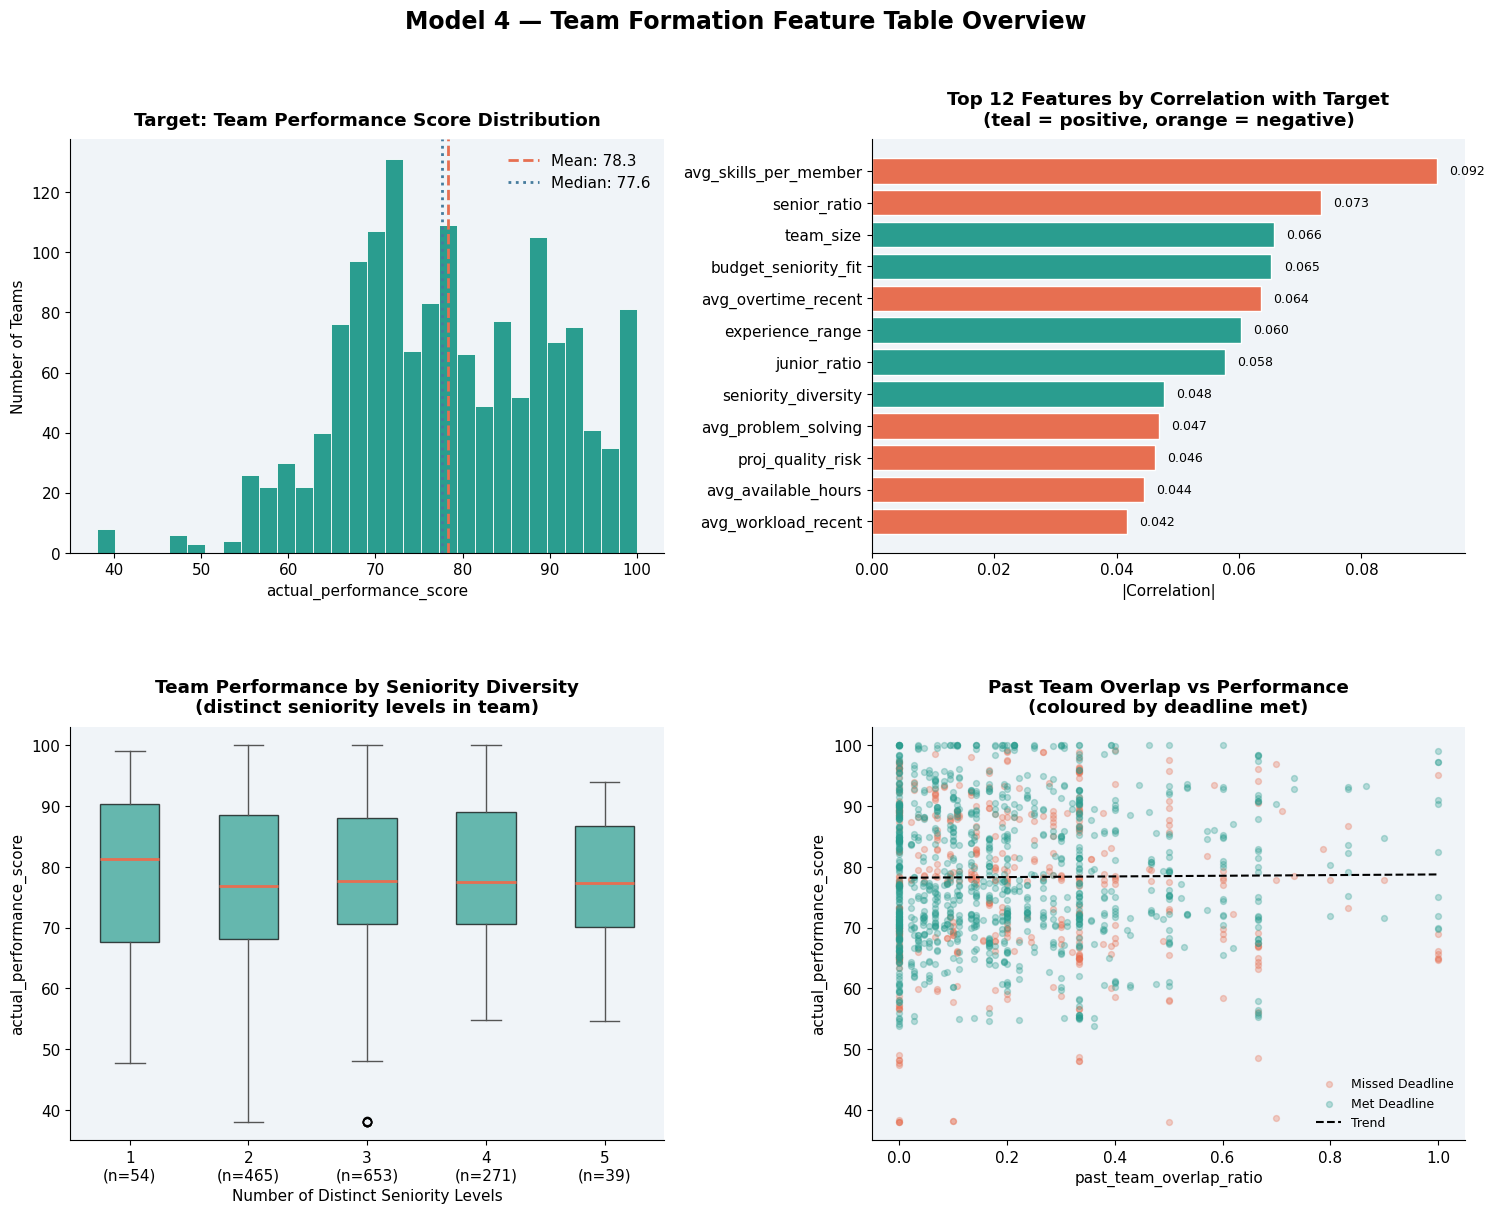

✅ Saved → FT3/feature_table_overview.png


In [16]:
# ── Cell 15 — Feature Table Visualizations (Presentation) ────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Load ──────────────────────────────────────────────────────
X       = pd.read_csv(f"{OUTPUT_DIR}/team_features.csv")
targets = pd.read_csv(f"{OUTPUT_DIR}/team_targets.csv")

# Merge for joint analysis
df = pd.concat([X, targets[['actual_performance_score', 'met_deadline', 'quality_rating']]], axis=1)

# ── Style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'     : 'sans-serif',
    'font.size'       : 11,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})
TEAL   = '#2A9D8F'
ORANGE = '#E76F51'
BLUE   = '#457B9D'
LIGHT  = '#F0F4F8'

fig = plt.figure(figsize=(18, 13), facecolor='white')
fig.suptitle('Model 4 — Team Formation Feature Table Overview',
             fontsize=17, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── Plot 1: Target Distribution ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(LIGHT)

scores = df['actual_performance_score']
ax1.hist(scores, bins=30, color=TEAL, edgecolor='white', linewidth=0.6)
ax1.axvline(scores.mean(),   color=ORANGE, linewidth=2, linestyle='--', label=f'Mean: {scores.mean():.1f}')
ax1.axvline(scores.median(), color=BLUE,   linewidth=2, linestyle=':',  label=f'Median: {scores.median():.1f}')
ax1.set_title('Target: Team Performance Score Distribution', fontweight='bold', pad=10)
ax1.set_xlabel('actual_performance_score')
ax1.set_ylabel('Number of Teams')
ax1.legend(frameon=False)

# ── Plot 2: Top 12 Features Correlated with Target ────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(LIGHT)

feature_cols = [c for c in X.columns]
corrs = df[feature_cols + ['actual_performance_score']]\
    .corr()['actual_performance_score']\
    .drop('actual_performance_score')\
    .abs()\
    .sort_values(ascending=False)\
    .head(12)

colors = [TEAL if df[c].corr(df['actual_performance_score']) > 0 else ORANGE for c in corrs.index]
bars = ax2.barh(corrs.index[::-1], corrs.values[::-1], color=colors[::-1], edgecolor='white')
ax2.set_title('Top 12 Features by Correlation with Target\n(teal = positive, orange = negative)',
              fontweight='bold', pad=10)
ax2.set_xlabel('|Correlation|')
for bar, val in zip(bars, corrs.values[::-1]):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

# ── Plot 3: Performance by Seniority Diversity ────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(LIGHT)

groups      = df.groupby('seniority_diversity')['actual_performance_score']
div_labels  = sorted(df['seniority_diversity'].unique())
box_data    = [groups.get_group(d).values for d in div_labels]
bp = ax3.boxplot(box_data, patch_artist=True, widths=0.5,
                 medianprops=dict(color=ORANGE, linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor(TEAL)
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp[element]:
        item.set_color('#555')

counts = [groups.get_group(d).count() for d in div_labels]
ax3.set_xticklabels([f'{d}\n(n={c})' for d, c in zip(div_labels, counts)])
ax3.set_title('Team Performance by Seniority Diversity\n(distinct seniority levels in team)',
              fontweight='bold', pad=10)
ax3.set_xlabel('Number of Distinct Seniority Levels')
ax3.set_ylabel('actual_performance_score')

# ── Plot 4: Past Overlap Ratio vs Performance (scatter) ───────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(LIGHT)

# Bin overlap ratio for cleaner scatter
met      = df[df['met_deadline'] == 1]
not_met  = df[df['met_deadline'] == 0]

ax4.scatter(not_met['past_team_overlap_ratio'], not_met['actual_performance_score'],
            alpha=0.3, s=18, color=ORANGE, label='Missed Deadline')
ax4.scatter(met['past_team_overlap_ratio'],     met['actual_performance_score'],
            alpha=0.3, s=18, color=TEAL,   label='Met Deadline')

# Trend line
z = np.polyfit(df['past_team_overlap_ratio'], df['actual_performance_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['past_team_overlap_ratio'].min(), df['past_team_overlap_ratio'].max(), 100)
ax4.plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle='--', label='Trend')

ax4.set_title('Past Team Overlap vs Performance\n(coloured by deadline met)',
              fontweight='bold', pad=10)
ax4.set_xlabel('past_team_overlap_ratio')
ax4.set_ylabel('actual_performance_score')
ax4.legend(frameon=False, fontsize=9)

# ── Save ──────────────────────────────────────────────────────
out_path = f"{OUTPUT_DIR}/feature_table_overview.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Saved → {out_path}")